### Mathematical Formulation
Let the raw tick stream be defined as a sequence of tuples $\{(p_i, v_i)\}_{i=1}^N$, representing the price and volume of the $i$-th transaction. We define the $k$-th bar as containing the sequence of ticks $i \in [T_{k-1} + 1, T_k]$.The index $T_k$ is determined by an arbitrary threshold $\theta$:Tick Bars: Sample when a fixed number of transactions have occurred.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t 1 \geq \theta_T \right\}$$Volume Bars: Sample when a fixed number of shares/contracts have been traded.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t v_i \geq \theta_V \right\}$$Dollar Bars: Sample when a fixed fiat value has been exchanged. This is generally the most robust of the three, as it naturally adjusts for significant price changes, stock splits, and inflation.$$T_k = \min \left\{ t : \sum_{i=T_{k-1}+1}^t p_i v_i \geq \theta_D \right\}$$

In [1]:
import numpy as np
import pandas as pd

def load_data_from_csv(csv_file: str) -> pd.DataFrame:
    # yfinance CSV export uses a 2-row header for MultiIndex columns and a standalone index-name row.
    # data = pd.read_csv(csv_file, header=[0, 1], skiprows=[2], index_col=0)

    # data.index = pd.to_datetime(data.index)
    # data.index.name = "timestamp"
    df = pd.read_csv(csv_file, parse_dates=['timestamp'])
    df.sort_values('timestamp', inplace=True)

    return df


output_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2021-01-01_to_2025-12-31_1Min.csv"

df = load_data_from_csv(output_file)

In [185]:
#Use a subset
# df = df[df['timestamp'] < '2022-01-01']

In [96]:
import pandas as pd

import pandas as pd

def compute_comparative_thresholds(df: pd.DataFrame, target_bars: int = 24, window: int = 21) -> pd.DataFrame:
    """
    Computes daily dynamic thresholds, strictly quarantining the burn-in period.
    """
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date
    df['dollar_volume'] = df['volume'] * df['vwap']
    
    daily_sums = df.groupby('date').agg(
        daily_ticks=('trade_count', 'sum'),
        daily_volume=('volume', 'sum'),
        daily_dollar=('dollar_volume', 'sum')
    )
    
    # CRITICAL FIX: min_periods=window forces the first W days to be NaN.
    # We use adjust=True (the mathematical default for incomplete windows) 
    # but still suppress the output until W days are reached to avoid the transient.
    expected_daily = daily_sums.ewm(span=window, min_periods=window, adjust=True).mean().shift(1)
    
    daily_thresholds = expected_daily / target_bars
    daily_thresholds.columns = ['Tick_Threshold', 'Volume_Threshold', 'Dollar_Threshold']
    
    # Dropping NaNs completely removes the initial W days from the threshold map.
    # When your bar-formation loop encounters these dates, it will find no threshold
    # and must be instructed to skip them.
    return daily_thresholds.dropna()

# Example Usage:
dynamic_thresholds_df = compute_comparative_thresholds(df, target_bars=24, window=63)
print(dynamic_thresholds_df.head())

            Tick_Threshold  Volume_Threshold  Dollar_Threshold
date                                                          
2021-04-05    22200.248147      3.873573e+06      1.504719e+09
2021-04-06    22073.346498      3.873571e+06      1.507141e+09
2021-04-07    21777.877218      3.829047e+06      1.491447e+09
2021-04-08    21460.509244      3.776265e+06      1.472298e+09
2021-04-09    21143.365742      3.729214e+06      1.455533e+09


In [97]:
mean_volume = df['volume'].mean()
print(f"Mean Volume: {mean_volume}")
mean_price = df['vwap'].mean()
print(f"Mean Price: {mean_price}")
mean_tick = df['trade_count'].mean()
print(f"Mean Tick Count: {mean_tick}")

max_volume = df['volume'].max()
print(f"Max Volume: {max_volume}")

Mean Volume: 93607.977288336
Mean Price: 484.28340744884736
Mean Tick Count: 754.5388159614777
Max Volume: 13760373.0


In [98]:
import numpy as np
import pandas as pd

def form_bars(df: pd.DataFrame, bar_type: str, dynamic_thresholds_df: pd.DataFrame) -> pd.DataFrame:
    """
    Forms bars using pre-aligned dynamic thresholds to maintain computational efficiency.
    """
    # 1. Pre-align the thresholds to the raw dataframe BEFORE entering the loop.
    threshold_col = f'{bar_type.capitalize()}_Threshold'
    if threshold_col not in dynamic_thresholds_df.columns:
         raise KeyError(f"Column '{threshold_col}' not found in dynamic_thresholds_df")

    # Extract dates to map the daily thresholds to intraday rows
    dates = pd.to_datetime(df['timestamp']).dt.date

    
    # Map the thresholds. 
    # Because EWMA shifts forward, day 1 will be NaN. We backfill (bfill) so day 1 
    # uses day 2's expectation, and forward-fill (ffill) as a safety net.
    mapped_thresholds = dates.map(dynamic_thresholds_df[threshold_col]).bfill().ffill()
    
    # Extract arrays
    times = df['timestamp'].values
    opens = df['open'].values
    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values
    volumes = df['volume'].values
    trade_counts = df['trade_count'].values
    vwaps = df['vwap'].values
    
    # Extract the pre-aligned threshold array
    thresholds = mapped_thresholds.values
    
    # Determine the driving variable for the accumulator
    if bar_type == 'tick':
        values = trade_counts
    elif bar_type == 'volume':
        values = volumes
    elif bar_type == 'dollar':
        values = vwaps * volumes
    else:
        raise ValueError("bar_type must be 'tick', 'volume', or 'dollar'")

    n = len(values)
    
    # Pre-allocate output arrays
    out_open = np.zeros(n)
    out_high = np.zeros(n)
    out_low = np.zeros(n)
    out_close = np.zeros(n)
    out_vol = np.zeros(n)
    out_vwap = np.zeros(n)
    out_times = np.empty(n, dtype=times.dtype)

    cumulative_sum = 0.0
    bar_idx = 0

    # State variables for the current bar formation
    current_high = -np.inf
    current_low = np.inf
    current_open = opens[0]
    current_vol = 0.0
    current_dollar_vol = 0.0

    for i in range(n):
        val = values[i]
        
        cumulative_sum += val
        current_vol += volumes[i]
        current_dollar_vol += (vwaps[i] * volumes[i])

        # Track the true extremes using the bucket's high/low
        if highs[i] > current_high: current_high = highs[i]
        if lows[i] < current_low:   current_low = lows[i]

        # The threshold check is now an O(1) array lookup
        if cumulative_sum >= thresholds[i]:
            out_open[bar_idx] = current_open
            out_high[bar_idx] = current_high
            out_low[bar_idx] = current_low
            out_close[bar_idx] = closes[i] 
            out_vol[bar_idx] = current_vol
            out_vwap[bar_idx] = current_dollar_vol / current_vol if current_vol > 0 else closes[i]
            out_times[bar_idx] = times[i]

            bar_idx += 1

            # Reset state for the next bar
            cumulative_sum = 0.0
            current_high = -np.inf
            current_low = np.inf
            if i + 1 < n:
                current_open = opens[i + 1]
            current_vol = 0.0
            current_dollar_vol = 0.0

    # Truncate and return
    bars_df = pd.DataFrame({
        'Open': out_open[:bar_idx],
        'High': out_high[:bar_idx],
        'Low': out_low[:bar_idx],
        'Close': out_close[:bar_idx],
        'Volume': out_vol[:bar_idx],
        'VWAP': out_vwap[:bar_idx]
    }, index=out_times[:bar_idx])
    
    return bars_df

In [99]:
# multiplier = max_volume/mean_volume
# print(multiplier)
dollar_bars = form_bars(df, bar_type='dollar', dynamic_thresholds_df=dynamic_thresholds_df)
tick_bars = form_bars(df, bar_type='tick', dynamic_thresholds_df=dynamic_thresholds_df)
volume_bars = form_bars(df, bar_type='volume', dynamic_thresholds_df=dynamic_thresholds_df)


Let $N_{k, \text{type}}$ be the number of bars generated in week $k$ for a given threshold $\theta_{\text{type}}$, where $\text{type} \in \{\text{tick}, \text{volume}, \text{dollar}\}$.The stability of the information arrival proxy is inversely proportional to the coefficient of variation of the weekly count:$$CV_{\text{type}} = \frac{\sigma(N_{\text{type}})}{\mu(N_{\text{type}})}$$A lower $CV$ indicates a sampling method that is robust to market regime shifts.

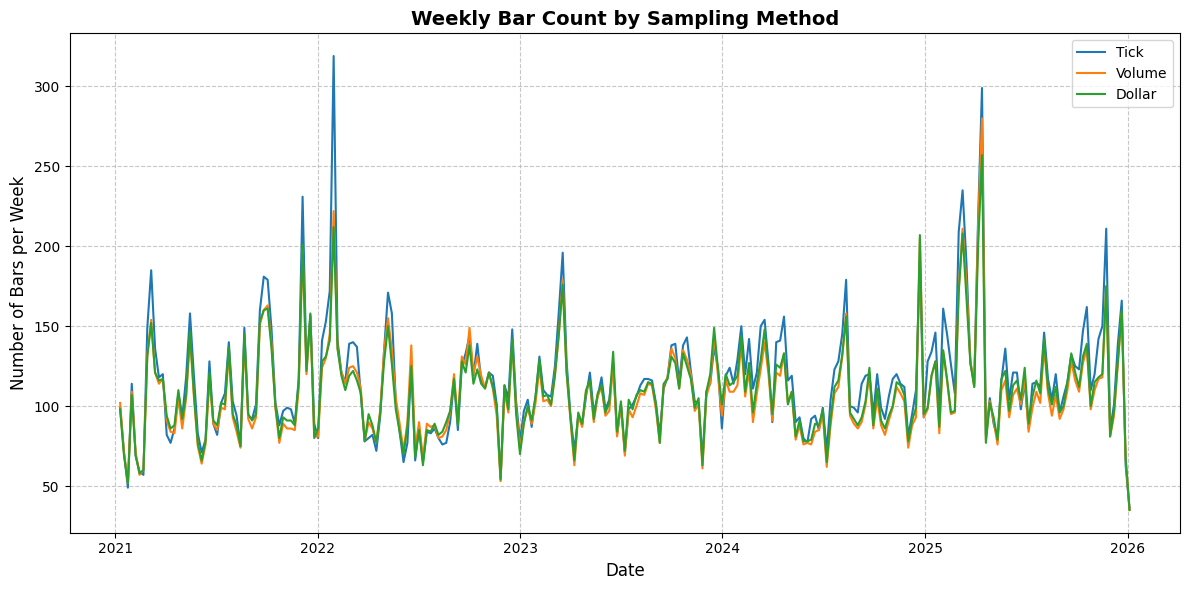

Stability Analysis (Coefficient of Variation):
              Mean        Std        CV
Dollar  109.122605  28.402199  0.260278
Volume  107.827586  29.757045  0.275969
Tick    115.333333  35.640405  0.309021


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_bar_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Calculates weekly bar counts, plots the time series, and computes the 
    Coefficient of Variation (CV) for stability analysis.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to its corresponding DataFrame of bars.
               DataFrames must have a DatetimeIndex.
    """
    weekly_counts = {}
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # Resample to weekly frequency and count the number of bars
        counts = df.resample('W').size()
        weekly_counts[bar_type] = counts
        
        # Plotting
        ax.plot(counts.index, counts.values, label=bar_type, linewidth=1.5)
        
    ax.set_title("Weekly Bar Count by Sampling Method", fontsize=14, fontweight='bold')
    ax.set_ylabel("Number of Bars per Week", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Calculate and display the Coefficient of Variation
    cv_results = {}
    for bar_type, counts in weekly_counts.items():
        mean_count = counts.mean()
        std_count = counts.std()
        cv = std_count / mean_count if mean_count > 0 else np.nan
        cv_results[bar_type] = {'Mean': mean_count, 'Std': std_count, 'CV': cv}
        
    cv_df = pd.DataFrame(cv_results).T
    print("Stability Analysis (Coefficient of Variation):")
    print(cv_df.sort_values('CV'))
    
    return cv_df


# Example usage (assuming tick_df, vol_df, dollar_df exist):
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}
stats_df = analyze_bar_stability(bars_dict)

In [101]:
import pandas as pd
import numpy as np

def compute_serial_correlation(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the first-order serial correlation of log returns for given bar types.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to a DataFrame containing a 'Close' column.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # Compute log returns. 
        # Using log returns is non-negotiable for additive multi-period properties.
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # Calculate lag-1 autocorrelation
        rho_1 = returns.autocorr(lag=1)
        
        # Calculate absolute autocorrelation (critical for microstructure evaluation)
        abs_rho_1 = np.abs(rho_1)
        
        results[bar_type] = {
            'rho_1': rho_1, 
            '|rho_1|': abs_rho_1,
            'Sample_Size': len(returns)
        }
        
    results_df = pd.DataFrame(results).T
    # Sort by the lowest absolute serial correlation
    return results_df.sort_values('|rho_1|')

# Example Usage:
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}
autocorr_stats = compute_serial_correlation(bars_dict)
print(autocorr_stats)



           rho_1   |rho_1|  Sample_Size
Volume -0.004347  0.004347      28142.0
Dollar  0.013154  0.013154      28480.0
Tick   -0.013162  0.013162      30101.0


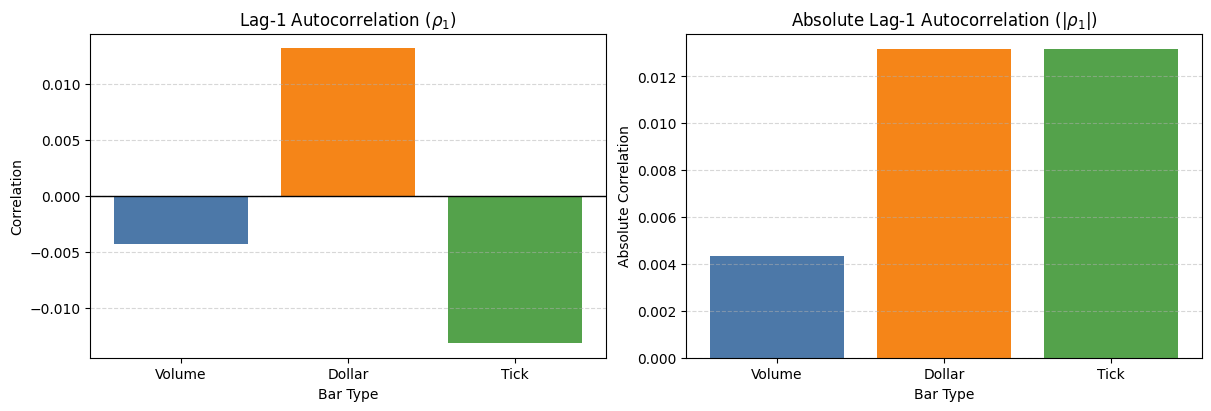

In [102]:
import matplotlib.pyplot as plt

# Plot serial correlation metrics by bar type
plot_df = autocorr_stats.copy()
plot_df.index = plot_df.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Signed lag-1 autocorrelation
axes[0].bar(plot_df.index, plot_df['rho_1'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Lag-1 Autocorrelation ($\\rho_1$)')
axes[0].set_ylabel('Correlation')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Absolute lag-1 autocorrelation (lower is better for microstructure noise)
axes[1].bar(plot_df.index, plot_df['|rho_1|'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Absolute Lag-1 Autocorrelation ($|\\rho_1|$)')
axes[1].set_ylabel('Absolute Correlation')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Bar Type')

plt.show()

Let $r_{i,m}$ be the log return of the $i$-th bar in month $m$, where $i \in [1, N_m]$.The sample variance for month $m$ is:$$V_m = \frac{1}{N_m - 1} \sum_{i=1}^{N_m} (r_{i,m} - \bar{r}_m)^2$$You are asking for the variance of this sequence of monthly variances, over $M$ total months:$$\text{Var}(V) = \frac{1}{M - 1} \sum_{m=1}^M (V_m - \bar{V})^2$$To correct your methodology, we must compute the relative stability:$$CV(V) = \frac{\sqrt{\text{Var}(V)}}{\bar{V}}$$A lower $CV(V)$ indicates that the sampling method successfully recovers a homoskedastic process across shifting market regimes
Why do dollar bars minimize $CV(V)$? The answer lies in the theory of subordinated stochastic processes, originally proposed by Clark (1973) and Mandelbrot.Financial prices do not evolve in chronological time $t$; they evolve in "transaction time" or "information time" $\tau$. If you model the log price $P(t)$ as a Brownian motion driven by an operational time variable $\tau(t)$, then chronological returns are conditionally normal but unconditionally leptokurtic (fat-tailed) because the variance is a random variable dictated by the trading rate.$$r_t \sim \mathcal{N}(0, \sigma^2 \Delta \tau_t)$$By sampling the market using dollar bars, you are forcing $\Delta \tau_t$ to be approximately constant. You are directly targeting the unobservable information arrival rate by using capital commitment as its proxy. If $\Delta \tau_t$ is rendered constant across months, the resulting return distribution $\mathcal{N}(0, \sigma^2 \Delta \tau)$ approaches true homoskedasticity, minimizing the variation of the monthly variances.

In [103]:
import pandas as pd
import numpy as np

def analyze_variance_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Partitions bar series into monthly subsets, computes the variance of returns 
    for each month, and evaluates the stability of those variances.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # 2. Partition into monthly subsets and compute variance
        # pd.Grouper is highly efficient for DatetimeIndex partitioning
        monthly_variances = returns.groupby(pd.Grouper(freq='ME')).var()
        
        # Drop months with insufficient data (e.g., NaN variances due to N=1)
        monthly_variances = monthly_variances.dropna()
        
        # 3. Compute statistics on the variances
        var_of_vars = monthly_variances.var()
        mean_var = monthly_variances.mean()
        
        # Dimensionless stability metric
        cv_of_vars = np.sqrt(var_of_vars) / mean_var if mean_var > 0 else np.nan
        
        results[bar_type] = {
            'Mean_Monthly_Variance': mean_var,
            'Variance_of_Variances': var_of_vars,
            'CV_of_Variances': cv_of_vars
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by the dimensionally correct metric, not the raw variance of variances
    return results_df.sort_values('CV_of_Variances')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
stability_stats = analyze_variance_stability(bars_dict)
print(stability_stats)

        Mean_Monthly_Variance  Variance_of_Variances  CV_of_Variances
Volume               0.000005           1.590004e-11         0.858773
Dollar               0.000005           1.602917e-11         0.869135
Tick                 0.000005           1.702505e-11         0.911333


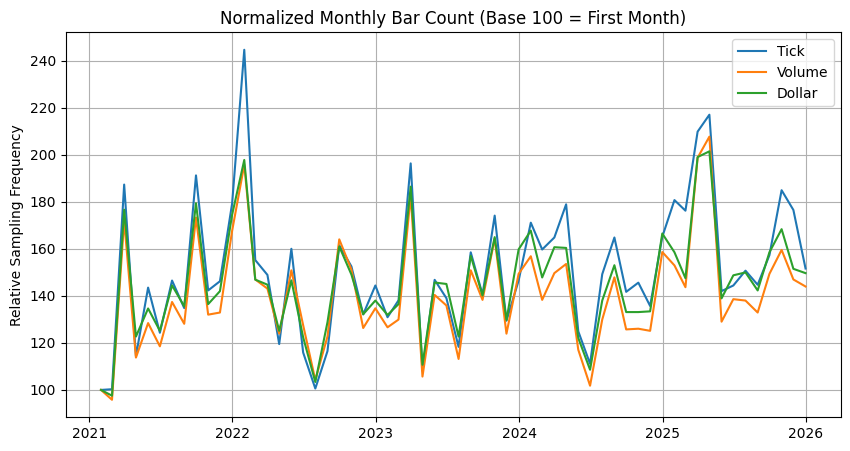

In [104]:
import matplotlib.pyplot as plt

def audit_sampling_heteroskedasticity(bars_dict: dict):
    """
    Plots the monthly bar counts. 
    If Dollar bars show a massive secular trend (up or down) compared to Tick/Volume,
    your threshold calibration is invalid.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for bar_type, df in bars_dict.items():
        # Count number of bars per month
        monthly_counts = df.resample('ME').size()
        
        # Normalize to base 100 for direct comparison of drift
        normalized_counts = (monthly_counts / monthly_counts.iloc[0]) * 100
        
        ax.plot(normalized_counts.index, normalized_counts.values, label=bar_type)
        
    ax.set_title("Normalized Monthly Bar Count (Base 100 = First Month)")
    ax.set_ylabel("Relative Sampling Frequency")
    ax.legend()
    plt.grid(True)
    plt.show()

# Run this:
audit_sampling_heteroskedasticity({'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars})

The Jarque-Bera test measures the goodness-of-fit of sample data to a normal distribution, based specifically on the sample skewness ($S$) and kurtosis ($K$). The test statistic is defined as:$$JB = \frac{n}{6} \left( S^2 + \frac{(K-3)^2}{4} \right)$$Under the null hypothesis that the data is normally distributed, the $JB$ statistic follows a Chi-squared distribution with two degrees of freedom ($\chi^2_2$).Chronological financial returns exhibit massive excess kurtosis ($K \gg 3$). They are leptokurtic because information arrives in clusters, causing volatility to scale non-linearly with clock time. By sampling in "information time" using volume or dollar bars, you are attempting to strip out the stochastic variance of the sampling interval itself (the subordinated stochastic process).Because dollar bars best proxy the true arrival of macroeconomic risk transfer, they suppress the excess kurtosis far more effectively than tick or volume bars, mathematically forcing the $JB$ statistic down.

In [105]:
import pandas as pd
import numpy as np
from scipy import stats

def compute_normality_tests(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the Jarque-Bera test statistic for log returns of given bar types.
    WARNING: This comparison is mathematically invalid if lengths of returns (n) differ significantly.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        n = len(returns)
        
        # 2. Compute Skewness and Kurtosis (Fisher definition where Normal Kurtosis = 0)
        skewness = stats.skew(returns)
        # scipy.stats.kurtosis computes EXCESS kurtosis by default (K-3)
        excess_kurtosis = stats.kurtosis(returns, fisher=True) 
        
        # 3. Compute Jarque-Bera
        jb_stat, p_value = stats.jarque_bera(returns)
        
        results[bar_type] = {
            'N': n,
            'Skewness': skewness,
            'Excess_Kurtosis': excess_kurtosis,
            'JB_Statistic': jb_stat,
            'p_value': p_value
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by lowest JB Statistic
    return results_df.sort_values('JB_Statistic')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
jb_stats = compute_normality_tests(bars_dict)
print(jb_stats)

              N  Skewness  Excess_Kurtosis   JB_Statistic  p_value
Dollar  28480.0 -0.099177        14.293637  242492.238053      0.0
Volume  28142.0 -0.317077        16.796472  331282.472793      0.0
Tick    30101.0  0.030320        20.041101  503752.043465      0.0
